In [ ]:
!pip install -q langchain langchain-openai langgraph langchain-community
!pip install -q ag2[azure_openai]
!pip install -U -q autogen-agentchat autogen-ext[openai] autogen-ext[azure]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━

In [ ]:
import os

os.environ['AZURE_OPENAI_ENDPOINT'] = "https://hkust.azure-api.net/"
os.environ['AZURE_OPENAI_API_VERSION'] = "2025-02-01-preview"
os.environ['AZURE_OPENAI_API_KEY'] = ""
os.environ['AZURE_OPENAI_MODEL'] = "gpt-5-mini"

In [ ]:
from langchain_openai import AzureChatOpenAI
from langchain_core.tools import tool

In [ ]:
llm = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    model=os.getenv('AZURE_OPENAI_MODEL'),
    temperature=0
)

# response = llm.invoke("Hi, how are you?")

In [ ]:
# response.content

In [ ]:
import json
import requests
import time

Alpha_Vantage_API_KEY = ''

In [ ]:
async def quote_endpoint(symbol: str = 'IBM', datatype: str = 'json') -> str:
    """
    This endpoint returns the latest price and volume information for a ticker of your choice. You can specify one ticker per API request.

    If you would like to query a large universe of tickers in bulk, you may want to try out our Realtime Bulk Quotes API, which accepts up to 100 tickers per API request.


    API Parameters
    ❚ Required: symbol

    The symbol of the global ticker of your choice. For example: symbol=IBM.

    ❚ Optional: datatype

    By default, datatype=json. Strings json and csv are accepted with the following specifications: json returns the quote data in JSON format; csv returns the quote data as a CSV (comma separated value) file.
    """
    url = f'https://www.alphavantage.co/query?function=GLOBAL_QUOTE&apikey={Alpha_Vantage_API_KEY}'
    params = {'symbol': symbol, 'datatype': datatype}
    r = requests.get(url, params=params)
    time.sleep(2)
    return json.dumps(r.json())

In [ ]:
async def market_news_sentiment(tickers: str = 'IBM', topics: str = None, time_from: str = None, time_to: str = None, sort: str = 'LATEST', limit: int = 10) -> str:
    """
    Looking for market news data to train your LLM models or to augment your trading strategy? You have just found it. This API returns live and historical market news & sentiment data from a large & growing selection of premier news outlets around the world, covering stocks, cryptocurrencies, forex, and a wide range of topics such as fiscal policy, mergers & acquisitions, IPOs, etc. This API, combined with our core stock API, fundamental data, and technical indicator APIs, can provide you with a 360-degree view of the financial market and the broader economy.


    API Parameters
    ❙ Optional: tickers

    The stock/crypto/forex symbols of your choice. For example: tickers=IBM will filter for articles that mention the IBM ticker; tickers=COIN,CRYPTO:BTC,FOREX:USD will filter for articles that simultaneously mention Coinbase (COIN), Bitcoin (CRYPTO:BTC), and US Dollar (FOREX:USD) in their content.

    ❙ Optional: topics

    The news topics of your choice. For example: topics=technology will filter for articles that write about the technology sector; topics=technology,ipo will filter for articles that simultaneously cover technology and IPO in their content. Below is the full list of supported topics:

    Blockchain: blockchain
    Earnings: earnings
    IPO: ipo
    Mergers & Acquisitions: mergers_and_acquisitions
    Financial Markets: financial_markets
    Economy - Fiscal Policy (e.g., tax reform, government spending): economy_fiscal
    Economy - Monetary Policy (e.g., interest rates, inflation): economy_monetary
    Economy - Macro/Overall: economy_macro
    Energy & Transportation: energy_transportation
    Finance: finance
    Life Sciences: life_sciences
    Manufacturing: manufacturing
    Real Estate & Construction: real_estate
    Retail & Wholesale: retail_wholesale
    Technology: technology
    ❙ Optional: time_from and time_to

    The time range of the news articles you are targeting, in YYYYMMDDTHHMM format. For example: time_from=20220410T0130. If time_from is specified but time_to is missing, the API will return articles published between the time_from value and the current time.

    ❙ Optional: sort

    By default, sort=LATEST and the API will return the latest articles first. You can also set sort=EARLIEST or sort=RELEVANCE based on your use case.

    ❙ Optional: limit

    By default, limit=10 and the API will return up to 10 matching results.
    """
    url = f'https://www.alphavantage.co/query?function=NEWS_SENTIMENT&apikey={Alpha_Vantage_API_KEY}'
    params = {'tickers': tickers, 'sort': sort, 'limit': limit}
    if topics: params['topics'] = topics
    if time_from: params['time_from'] = time_from
    if time_to: params['time_to'] = time_to
    r = requests.get(url, params=params)
    time.sleep(2)
    return json.dumps(r.json())

In [ ]:
async def company_overview(symbol: str = 'IBM') -> str:
    """
    This API returns the company information, financial ratios, and other key metrics for the equity specified. Data is generally refreshed on the same day a company reports its latest earnings and financials.


    API Parameters
    ❙ Required: symbol

    The symbol of the ticker of your choice. For example: symbol=IBM.
    """
    url = f'https://www.alphavantage.co/query?function=OVERVIEW&symbol={symbol}&apikey={Alpha_Vantage_API_KEY}'
    r = requests.get(url)
    time.sleep(2)
    return json.dumps(r.json())

In [ ]:
async def earnings_estimates(symbol: str = 'IBM') -> str:
    """
    This API returns the annual and quarterly EPS and revenue estimates for the company of interest, along with analyst count and revision history.


    API Parameters
    ❙ Required: symbol

    The symbol of the ticker of your choice. For example: symbol=IBM.
    """
    url = f'https://www.alphavantage.co/query?function=EARNINGS_ESTIMATES&symbol={symbol}&apikey={Alpha_Vantage_API_KEY}'
    r = requests.get(url)
    time.sleep(2)
    return json.dumps(r.json())

In [ ]:
import json
import pandas as pd

async def get_technical_indicator(function: str, symbol: str = 'IBM', interval: str = 'daily', time_period: int = 10, series_type: str = 'open', month: str = None) -> str:
    """
    Unified function to fetch technical indicators from Alpha Vantage in the last four months. Availables ones include SMA, EMA, RSI, and ADX. After execution, the data will be saved to the path: '{symbol}_data_{function}_{interval}_{time_period}.csv' and the path will be returned. Below is the format of the data frame:
        timestamp       SMA
    0  2026-04-23  245.3020
    1  2026-04-22  246.1630
    2  2026-04-21  245.5750
    3  2026-04-20  244.7070
    4  2026-04-17  244.0210

    API Parameters
    ❙ Required: function

    The technical indicator of your choice. For example, function=SMA

    ❙ Required: symbol

    The name of the ticker of your choice. For example: symbol=IBM

    ❙ Required: interval

    Time interval between two consecutive data points in the time series. The following values are supported: 1min, 5min, 15min, 30min, 60min, daily, weekly, monthly

    ❙ Optional: month

    By default, this parameter is not set and the technical indicator values will be calculated based on the default length of the underlying intraday, daily, weekly, or monthly time series data. You can use the month parameter (in YYYY-MM format) to return technical indicators for a specific month in history. For example, month=2009-01.

    ❙ Required:time_period

    Number of data points used to calculate each moving average value. Positive integers are accepted (e.g., time_period=60, time_period=200)

    ❙ Required: series_type

    The desired price type in the time series. Four types are supported: close, open, high, low
    """
    url = f'https://www.alphavantage.co/query?apikey={Alpha_Vantage_API_KEY}'
    params = {
        'function': function,
        'symbol': symbol,
        'interval': interval,
        'time_period': time_period,
        'series_type': series_type,
    }
    if month: params['month'] = month
    response = requests.get(url, params=params).json()
    time.sleep(2)
    # print(response)
    response[f'Technical Analysis: {function}'] = {key: value for key,value in response[f'Technical Analysis: {function}'].items() if key >= '2025-12-01'}

    # Create DataFrame
    df = pd.DataFrame.from_dict(response[f'Technical Analysis: {function}'], orient='index')
    df.index.name = 'timestamp'
    df.reset_index(inplace=True)

    # Save to file
    os.makedirs('coding', exist_ok=True)
    path = f'coding/{symbol}_data_{function}_{interval}_{time_period}.csv'
    df.to_csv(path, index=False)
    # print(df.head())

    return f'{symbol}_data_{function}_{interval}_{time_period}.csv'

# await get_technical_indicator('RSI')

In [ ]:
# @title
config_list = [
    {
        "model": os.getenv('AZURE_OPENAI_MODEL'),
        "api_key": os.getenv("AZURE_OPENAI_API_KEY"),
        "base_url": os.getenv("AZURE_OPENAI_ENDPOINT"),
        "api_type": "azure",
        "api_version": os.getenv("AZURE_OPENAI_API_VERSION"),
        "temperature": 1.0
    }
]

In [ ]:
# @title
from autogen import AssistantAgent, UserProxyAgent, ConversableAgent, GroupChat, GroupChatManager
from autogen.coding import LocalCommandLineCodeExecutor

In [ ]:
# @title
# No streaming

llm_config = {"config_list": config_list}

# Create an Assistant Agent
assistant = AssistantAgent(
    name="assistant",
    llm_config=llm_config,
    system_message="You are a helpful financial advisor who decides what stock ticker symbol \
    to buy or sell. You will write Python code and make tool calls before making any decisions. \
    Make sure all of the outputs of the code are stored in a csv file named 'report.csv'.You \
    may ask the human for clarifications whenever needed. Clearly explain to the human why \
    you are executing certain steps and always ask for permission to buy or sell with \
    supporting evidence.",
)

# Create a User Proxy Agent to execude code
user_proxy = UserProxyAgent(
    name="user_proxy",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=5,
    code_execution_config={
        "executor": LocalCommandLineCodeExecutor(work_dir="coding", timeout=30),
    },
)

human = ConversableAgent(
    name="human",
    human_input_mode="ALWAYS",  # prompts for human input at each step
)

groupchat = GroupChat(
    agents=[assistant, user_proxy, human],
    speaker_selection_method="auto"
)

manager = GroupChatManager(
    name="group_manager",
    groupchat=groupchat,
    llm_config=llm_config
)

# Start the conversation
# chat_result = human.initiate_chat(
#     recipient=manager,
#     message="Should I buy or sell my current IBM shares?",
#     max_turns=5,
#     summary_method="reflection_with_llm"  # Optional: final LLM-generated summary
# )

In [ ]:
# @title
print("\n Final Summary:")
print(chat_result.summary)

## AI-refactored to support streaming and tool calling in the newest version of autogen

In [ ]:
async def list_data_files(directory: str = "coding") -> list[str]:
    """List all CSV data filenames in the specified directory."""
    if not os.path.exists(directory):
        return []
    files = os.listdir(directory)
    return [f for f in files if f.endswith('.csv')]

# await list_data_files('coding')

In [ ]:
shares = {'IBM': 100, 'AAPL': 50, 'GOOGL': 10}

async def check_profile() -> dict:
    """Check the profile of the user. (How many shares the user has.)"""
    global shares
    return shares

async def buy(symbol: str, quantity: int) -> str:
    """Buy shares of a stock equal to the quantity."""
    global shares
    shares[symbol] = shares.get(symbol, 0) + quantity
    return f"Bought {quantity} shares of {symbol}."

async def sell(symbol: str, quantity: int) -> str:
    """Sell shares of a stock equal to the quantity."""
    global shares
    shares[symbol] = max(shares.get(symbol, 0) - quantity, 0)
    return f"Sold {quantity} shares of {symbol}."

In [ ]:
import sys
from unittest.mock import MagicMock
sys.modules['asyncio_atexit'] = MagicMock()
sys.modules['docker'] = MagicMock()

In [ ]:
import asyncio
from autogen_agentchat.agents import AssistantAgent, CodeExecutorAgent, UserProxyAgent
from autogen_agentchat.teams import SelectorGroupChat, MagenticOneGroupChat, RoundRobinGroupChat
from autogen_agentchat.conditions import MaxMessageTermination, TextMentionTermination
from autogen_agentchat.ui import Console
from autogen_core import CancellationToken
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient
from autogen_ext.code_executors import LocalCommandLineCodeExecutor
from autogen_core.models import SystemMessage, UserMessage


# ============================================================================
# 1. AZURE OPENAI CONFIGURATION (v0.4: Direct client instantiation)
# ============================================================================

# Your existing config_list mapped to v0.4 AzureOpenAIChatCompletionClient
# v0.4 no longer uses config_list dicts - uses explicit client constructors
model_client = AzureOpenAIChatCompletionClient(
    model=os.getenv("AZURE_OPENAI_MODEL"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    temperature=1.0,
    # Optional: seed for reproducibility
    seed=42,
    # Optional: max tokens
    max_tokens=4096,
)


# ============================================================================
# 2. AGENT DEFINITIONS
# ============================================================================

financial_advisor = AssistantAgent(
    name="financial_advisor",
    model_client=model_client,
    tools=[quote_endpoint, market_news_sentiment, company_overview, earnings_estimates, get_technical_indicator, \
           list_data_files, check_profile, buy, sell],
    # system_message=(
    #     "You are a helpful financial advisor who decides what stock ticker symbol "
    #     "to buy or sell. You will write Python code to analyze the technical indicators and pass it to the code_executor agent first before any tool calls. "
    #     "Make sure all of the outputs of the code are stored in a csv file named 'report.csv'. "
    #     "Afterward, you will then complement that information with appropriate tool call results before coming to any conclusions. "
    #     "Do not make repetitive or redundant tool calls."
    #     "You may ask the human for clarifications or instructions whenever needed. "
    #     "Clearly explain to the human why you are executing certain steps and making certain tool calls."
    #     "Always ask for permission to buy or sell with supporting evidence in the end."
    # ),
    system_message=(
        "You are a helpful financial advisor who decides what stock ticker symbol "
        "to buy or sell. Focus on a maximum of 3 technical indicators. "
        "Before you make any tool calls to fetch technical indicator data, always check first if there are any pre-existing data files "
        "already available to avoid fetching redundant indicator data."
        "You will then make tool calls (only if necessary) to gather more information of the stock and then "
        "write Python code to analyze the technical indicators stored in csv files for the code_executor agent to execute. "
        "Afterward, you will fetch the code output and analyze all the available information before coming to any conclusions. "
        "You may ask the human for clarifications or instructions whenever needed. "
        "Clearly explain to the human why you are executing certain steps and making certain tool calls."
        "Always ask for permission to buy or sell with supporting evidence and afterward always"
        "let the user know if they can end the conversation now."
    ),
    model_client_stream=True,  # Enable streaming tokens
)

code_executor = CodeExecutorAgent(
    name="code_executor",
    code_executor=LocalCommandLineCodeExecutor(
        work_dir="coding",
        timeout=30,
    ),
)

human_proxy = UserProxyAgent(
    name="human",
)


# ============================================================================
# 3. TEAM CONFIGURATION
# ============================================================================

team = RoundRobinGroupChat(
    participants=[financial_advisor, human_proxy, code_executor],
    # model_client=model_client,
    termination_condition=(
        TextMentionTermination("QUIT") |
        MaxMessageTermination(max_messages=25)
    ),
)


# ============================================================================
# 4. STREAMING EXECUTION
# ============================================================================

async def run_investment_analysis(task: str):
    """Run with real-time streaming output."""
    cancellation_token = CancellationToken()

    try:
        print("=" * 60)
        print("STARTING INVESTMENT ANALYSIS WITH AZURE OPENAI")
        print("=" * 60)

        stream = team.run_stream(
            task=task,
            cancellation_token=cancellation_token
        )

        # Console consumes stream and prints messages as they arrive
        result = await Console(stream, output_stats=True)

        print("\n" + "=" * 60)
        print("ANALYSIS COMPLETE")
        print(f"Stop reason: {result.stop_reason}")
        print("=" * 60)

    except asyncio.CancelledError:
        print("\nOperation was cancelled.")

    return result


/tmp/ipykernel_8403/2689380214.py:68: UserWarning: Using LocalCommandLineCodeExecutor may execute code on the local machine which can be unsafe. For security, it is recommended to use DockerCommandLineCodeExecutor instead. To install Docker, visit: https://docs.docker.com/get-docker/
  code_executor=LocalCommandLineCodeExecutor(
/tmp/ipykernel_8403/2689380214.py:66: UserWarning: No approval function set for CodeExecutorAgent. This means code will be executed automatically without human oversight. For security, consider setting an approval_func to review and approve code before execution. See the CodeExecutorAgent documentation for examples of approval functions.
  code_executor = CodeExecutorAgent(


In [ ]:
message="Should I buy or sell my current IBM shares?"
# result = await run_investment_analysis(message)

In [ ]:
# result

#Interface

In [ ]:
async def run_investment_analysis_demo(task: str):
    """Run with real-time streaming output."""
    cancellation_token = CancellationToken()

    print("=" * 60)
    print("STARTING INVESTMENT ANALYSIS WITH AZURE OPENAI")
    print("=" * 60)

    output = ""

    try:
        stream = team.run_stream(
            task=task,
            cancellation_token=cancellation_token
        )

        try:
            async for event in stream:
                try:
                    text_chunk = ""

                    if isinstance(event, str):
                        text_chunk = event

                    elif hasattr(event, "content"):
                        content = event.content

                        if isinstance(content, str):
                            text_chunk = content

                        elif isinstance(content, list):
                            for item in content:
                                if isinstance(item, str):
                                    text_chunk += item
                                elif isinstance(item, dict):
                                    text_chunk += item.get("text", "")
                                else:
                                    text_chunk += str(item)
                        else:
                            text_chunk = str(content)

                    if text_chunk:
                        output += text_chunk
                        yield output

                except Exception as e:
                    print("Skipping bad event:", e)
                    continue

        except Exception as e:
            # 🔴 THIS IS THE IMPORTANT PART
            print("STREAM ERROR:", e)
            yield output + f"\n\n[STREAM ERROR: {e}]"

    except Exception as e:
        print("FATAL ERROR:", e)
        yield f"[FATAL ERROR: {e}]"

    print("STREAM FINISHED CLEANLY")

In [ ]:
import gradio as gr

with gr.Blocks() as inv_demo:
  title = "Investment Agent"
  gr.HTML(f"""
  <h1 style='text-align: center;'>Investment Agent</h1>
  <h2 style='text-align: center;'>This tool provides insights for investment decisions.</h2>
  <h3 style='text-align: center;'>Type in any additional information you wish to provide to the agent, or simply 'continue' to proceed when prompted.</h3>
  <h3 style='text-align: center;'>Type in 'QUIT' whenever you want to terminate the conversation.</h4>""")

  chatbot = gr.Chatbot(height=500)
  msg = gr.Textbox()
  gr.HTML("<h3 style='text-align: center;'>(Please note that these information are for reference only, as this tool will not be responsible for any financial loss caused by human decision.)</h3>")
  state = gr.State([])

  async def respond(user_message, history):
      history = history or []

      # add user message
      history.append(("user", user_message))

      final_output = ""

      # stream response
      async for update in run_investment_analysis_demo(user_message):
          final_output = update
          yield history + [("assistant", update)], history

      # ✅ persist assistant message
      history.append(("assistant", final_output))

      # final state update
      yield history, history

  msg.submit(
      respond,
      inputs=[msg, state],
      outputs=[chatbot, state]   # ✅ IMPORTANT
  )

inv_demo.launch(debug=True)

/tmp/ipykernel_8403/1267427389.py:11: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(height=500)
/tmp/ipykernel_8403/1267427389.py:11: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=500)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://eb2252faccf7d82372.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


STARTING INVESTMENT ANALYSIS WITH AZURE OPENAI
Enter your response: continue
Enter your response: continue
Enter your response: continue
Enter your response: run the python code
Enter your response: So what do you recommend?
Enter your response: Sell 20% of my shares.
Enter your response: QUIT
STREAM FINISHED CLEANLY
Keyboard interruption in main thread... closing server.


KeyboardInterrupt: 

# Benchmarking

In [ ]:
!pip install -q matplotlib seaborn pandas numpy

In [ ]:
# ── Add as many prompts as your API quota allows ──────────────────────────────
PROMPTS = [
    "Should I buy or sell my current IBM shares?",
    "Analyse MSFT and tell me if I should add to my position.",
    "Is now a good time to take profits on my AAPL holdings?",
    "Any noteworthy news from IBM recently?",
    "Should I invest in the company, 'ISOMers'?",
]

results = []
for i, prompt in enumerate(PROMPTS):
    # if i < 3:
    #     continue
    print(f"\n{'='*60}\n  Session {i+1}/{len(PROMPTS)}: {prompt}\n{'='*60}")
    results.append(await run_investment_analysis(prompt))

await model_client.close()
print("\n✅ All sessions complete")


  Session 1/5: Should I buy or sell my current IBM shares?
STARTING INVESTMENT ANALYSIS WITH AZURE OPENAI
---------- TextMessage (user) ----------
Should I buy or sell my current IBM shares?


ERROR:autogen_core:Error processing publish message for financial_advisor_a53b4d7b-38b7-45dc-95ed-9b7ff8cbbcc8/a53b4d7b-38b7-45dc-95ed-9b7ff8cbbcc8
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/openai/_base_client.py", line 1630, in request
    response = await self._send_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_client.py", line 829, in _send_request
    return await self._send_with_auth_retry(request, stream=stream, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_client.py", line 807, in _send_with_auth_retry
    response = await super()._send_request(request, stream=stream, **kwargs)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_base_client.py", line 1553, in _send_request
    return await self._client.s

RuntimeError: APIConnectionError: Connection error.
Traceback:
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/openai/_base_client.py", line 1630, in request
    response = await self._send_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/openai/_client.py", line 829, in _send_request
    return await self._send_with_auth_retry(request, stream=stream, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/openai/_client.py", line 807, in _send_with_auth_retry
    response = await super()._send_request(request, stream=stream, **kwargs)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/openai/_base_client.py", line 1553, in _send_request
    return await self._client.send(request, stream=stream, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
print(len(results))
results[-1]

5


TaskResult(messages=[TextMessage(id='43459daf-59ff-4586-a51d-813e163a12b3', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 26, 2, 5, 0, 208300, tzinfo=datetime.timezone.utc), content="Should I invest in the company, 'ISOMers'?", type='TextMessage'), TextMessage(id='f0fd70e0-6416-40a8-8cfd-f22aefb05339', source='code_executor', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 26, 2, 5, 0, 211535, tzinfo=datetime.timezone.utc), content='No code blocks found in the thread. Please provide at least one markdown-encoded code block to execute (i.e., quoting code in ```python or ```sh code blocks).', type='TextMessage'), TextMessage(id='f6296667-3133-40fa-a87c-2f7fcb7cb211', source='financial_advisor', models_usage=RequestUsage(prompt_tokens=0, completion_tokens=0), metadata={}, created_at=datetime.datetime(2026, 4, 26, 2, 5, 8, 549614, tzinfo=datetime.timezone.utc), content='I can help — but I need a bit more information before giving

In [ ]:
from pathlib import Path
from datetime import datetime
import pickle

# Persist raw run artifacts so notebook/kernel restarts do not lose completed sessions.
RUNS_DIR = Path("saved_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_file = RUNS_DIR / f"investment_results_{run_stamp}.pkl"

payload = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "prompts": PROMPTS,
    "results": results,
}

with run_file.open("wb") as f:
    pickle.dump(payload, f)

print(f"Saved session bundle: {run_file.resolve()}")
print("You can download this .pkl file and reload it in a future session.")

def load_saved_results(path: str | Path):
    p = Path(path)
    with p.open("rb") as f:
        data = pickle.load(f)
    return data["prompts"], data["results"], data

# Example:

# prompts_loaded, results_loaded, raw_bundle = load_saved_results("saved_runs/investment_results_YYYYMMDD_HHMMSS.pkl")

Saved session bundle: /content/saved_runs/investment_results_20260426_021531.pkl
You can download this .pkl file and reload it in a future session.


In [ ]:
_, results, _ = load_saved_results("saved_runs/investment_results_20260426_021531.pkl")
len(results)

5

In [ ]:
model_client = AzureOpenAIChatCompletionClient(
    model=os.getenv("AZURE_OPENAI_MODEL"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    temperature=1.0,
    # Optional: seed for reproducibility
    seed=42,
    # Optional: max tokens
    max_tokens=4096,
)

In [ ]:
import re
from collections import Counter

# ── Shared regex patterns ─────────────────────────────────────────────────────
EVIDENCE_RE   = re.compile(
    r"(RSI|MACD|EMA|SMA|moving average|P/E|pe ratio|earnings|EPS|revenue|"
    r"sentiment|price target|support|resistance|volume|bollinger|stochastic|"
    r"\$[\d,.]+|\d+\.\d+%)", re.I
)
PERMISSION_RE = re.compile(
    r"(permission|approve|authoris|authoriz|go.ahead|confirm.*(buy|sell)|proceed.*(buy|sell))", re.I
)
DECISION_RE   = re.compile(r"\b(buy|sell|hold|purchase|divest|exit|accumulate|maintain)\b", re.I)
CODE_BLOCK_RE = re.compile(r"```(?:python|bash)?\n.+?```", re.DOTALL)
ERROR_RE      = re.compile(r"(Traceback|Error:|Exception:|failed|SyntaxError)", re.I)

# Stopwords for instruction-adherence token matching
STOPWORDS = {
    "i","me","my","the","a","an","is","it","to","do","this","that","and","or",
    "but","in","on","at","for","with","you","your","we","our","please","can",
    "will","should","would","could","have","has","been","be","are","was","were",
    "just","now","so","ok","okay","sure","yes","no","not","also","then","than",
}


# ─────────────────────────────────────────────────────────────────────────────
# Helper: pull tool-call names out of a message list.
# In autogen v0.4 a ToolCallRequestMessage has content = list[ToolCall].
# Each ToolCall has a .name attribute.
# ─────────────────────────────────────────────────────────────────────────────
def extract_tool_calls(messages: list) -> list[dict]:
    calls = []
    for msg in messages:
        content = getattr(msg, "content", None)
        if isinstance(content, list):            # ToolCallRequestMessage
            for item in content:
                name = getattr(item, "name", None)
                if name:                         # it's a ToolCall object
                    args = getattr(item, "arguments", {})
                    calls.append({"name": name, "args": args})
    return calls


# ── B1 override: ignore list_data_files in efficiency checks ───────────────────
B1_EXCLUDED_TOOLS = {"list_data_files"}
# ─────────────────────────────────────────────────────────────────────────────
# B1 — Tool Call Efficiency
#   total_calls : int    — how many tool calls fired
#   redundancy  : float  — fraction that are exact duplicates (name + args)
# ─────────────────────────────────────────────────────────────────────────────
def tool_call_efficiency(messages: list) -> dict:
    calls = extract_tool_calls(messages)
    scored_calls = [c for c in calls if c["name"] not in B1_EXCLUDED_TOOLS]

    if not scored_calls:
        return {
            "total": 0,
            "redundancy": 0.0,
            "per_tool": {},
            "calls": [],
            "excluded_calls": len(calls),
            "excluded_tools": sorted(B1_EXCLUDED_TOOLS),
        }

    seen, dupes = set(), 0
    for c in scored_calls:
        key = (c["name"], json.dumps(c["args"], sort_keys=True, default=str))
        if key in seen:
            dupes += 1
        else:
            seen.add(key)

    return {
        "total": len(scored_calls),
        "redundancy": dupes / len(scored_calls),
        "per_tool": Counter(c["name"] for c in scored_calls),
        "calls": scored_calls,
        "excluded_calls": len(calls) - len(scored_calls),
        "excluded_tools": sorted(B1_EXCLUDED_TOOLS),
    }


# ─────────────────────────────────────────────────────────────────────────────
# B2 — Code Execution Success Rate
#   Returns list of booleans, one per code_executor turn.
# ─────────────────────────────────────────────────────────────────────────────
def code_execution_results(messages: list) -> list[bool]:
    outcomes = []
    for msg in messages:
        if getattr(msg, "source", "") == "code_executor":
            content = getattr(msg, "content", "") or ""
            if isinstance(content, str) and content.strip():
                outcomes.append(not bool(ERROR_RE.search(content)))
    return outcomes


# ── B3: Evidence Quality (LLM-as-a-judge) ─────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
async def evidence_quality_judge(messages: list) -> dict:
    target_message = ""
    for msg in reversed(messages):
        if getattr(msg, "source", "") != "financial_advisor":
            continue
        content = getattr(msg, "content", "") or ""
        if isinstance(content, str) and PERMISSION_RE.search(content):
            target_message = content
            break

    if not target_message:
        return {
            "score": None,
            "rationale": "No permission request was needed in this session.",
            "strengths": [],
            "weaknesses": [],
            "snippet": "",
        }

    client = model_client
    prompt = (
        "Score the evidence quality of this permission request from 1 to 10.\n\n"
        "Return valid JSON only. Do not include markdown, code fences, or extra text.\n"
        "Use exactly this schema:\n"
        "{\n"
        '  "score": 1,\n'
        '  "rationale": "short explanation",\n'
        '  "strengths": ["item 1", "item 2"],\n'
        '  "weaknesses": ["item 1", "item 2"]\n'
        "}\n\n"
        f"Permission request:\n{target_message}"
    )

    response = await client.create([
        SystemMessage(content="You are a strict evaluator. Return valid JSON only."),
        UserMessage(content=prompt, source="judge_user"),
    ])

    raw_text = getattr(response, "content", "")
    if isinstance(raw_text, list):
        raw_text = "".join(str(getattr(item, "content", item)) for item in raw_text)
    parsed = json.loads(str(raw_text))
    return {
        "score": max(1, min(10, int(parsed["score"]))),
        "rationale": parsed.get("rationale", ""),
        "strengths": parsed.get("strengths", []),
        "weaknesses": parsed.get("weaknesses", []),
        "snippet": target_message[:300],
    }


# ─────────────────────────────────────────────────────────────────────────────
# B4 — Human Instruction Adherence (semantic judge)
#   For each human message, scores whether the next advisor response semantically
#   addresses the human intent (1-10), and tracks constraint acknowledgement.
# ─────────────────────────────────────────────────────────────────────────────
CONSTRAINT_RE = re.compile(
    r"\b(only|must|should|don't|do not|avoid|focus on|no|without|exclude|limit)\b", re.I
)

async def human_instruction_adherence(messages: list) -> list[dict]:
    exchanges = []

    for i, msg in enumerate(messages):
        if getattr(msg, "source", "") != "human":
            continue
        human_text = getattr(msg, "content", "") or ""
        if not isinstance(human_text, str) or not human_text.strip():
            continue

        advisor_text = ""
        advisor_turn = None
        for j in range(i + 1, len(messages)):
            if getattr(messages[j], "source", "") == "financial_advisor":
                advisor_text = getattr(messages[j], "content", "") or ""
                advisor_turn = j
                break

        if not advisor_text:
            continue

        has_constraint = bool(CONSTRAINT_RE.search(human_text))
        constraint_ack = False
        if has_constraint:
            overlap_tokens = set(re.findall(r"[a-z]{3,}", human_text.lower())) - STOPWORDS
            advisor_tokens = set(re.findall(r"[a-z]{3,}", advisor_text.lower()))
            constraint_ack = len(overlap_tokens & advisor_tokens) > 0

        client = model_client
        prompt = (
            "Score from 1 to 10 how well the advisor response semantically addresses the human message.\n\n"
            "Return valid JSON only. Do not include markdown, code fences, or extra text.\n"
            "Use exactly this schema:\n"
            "{\n"
            '  "score": 1,\n'
            '  "rationale": "short explanation"\n'
            "}\n\n"
            f"Human message:\n{human_text}\n\n"
            f"Advisor response:\n{advisor_text}"
        )

        response = await client.create([
            SystemMessage(content="You are a strict evaluator. Return valid JSON only."),
            UserMessage(content=prompt, source="judge_user"),
        ])
        raw_text = getattr(response, "content", "")
        if isinstance(raw_text, list):
            raw_text = "".join(str(getattr(item, "content", item)) for item in raw_text)
        parsed = json.loads(str(raw_text))
        score = max(1, min(10, int(parsed["score"])))
        rationale = parsed.get("rationale", "")

        exchanges.append({
            "turn": advisor_turn,
            "human": human_text[:180],
            "advisor": advisor_text[:180],
            "score": score,
            "rationale": rationale,
            "has_constraint": has_constraint,
            "constraint_ack": constraint_ack,
        })

    return exchanges


print("✅ Parsers defined")

✅ Parsers defined


In [ ]:
import numpy as np

# ── Run all parsers over every session ────────────────────────────────────────
def _as_messages(session_obj):
    """Accept either TaskResult-like objects or raw message lists."""
    if hasattr(session_obj, "messages"):
        return session_obj.messages
    return session_obj

results_messages = [_as_messages(r) for r in results]
n_sessions = len(results_messages)

# Keep session labels aligned to actual completed runs (results), not planned prompts.
sessions = [f"S{i+1}" for i in range(n_sessions)]
prompt_labels = [
    (PROMPTS[i][:42] + "…") if i < len(PROMPTS) and len(PROMPTS[i]) > 42 else (PROMPTS[i] if i < len(PROMPTS) else "(no prompt)")
    for i in range(n_sessions)
]

b1 = [tool_call_efficiency(m) for m in results_messages]
b2 = [code_execution_results(m) for m in results_messages]

# Run judges without sharing a single client object across tasks.
# This avoids closed-client races if a shared global client exists in notebook state.
b3 = []
for m in results_messages:
    b3.append(await evidence_quality_judge(m))

b4 = []
for m in results_messages:
    b4.append(await human_instruction_adherence(m))

# Safety trim in case notebook state was partially executed earlier.
aligned_n = min(len(sessions), len(prompt_labels), len(b1), len(b2), len(b3), len(b4))
sessions = sessions[:aligned_n]
prompt_labels = prompt_labels[:aligned_n]
b1 = b1[:aligned_n]
b2 = b2[:aligned_n]
b3 = b3[:aligned_n]
b4 = b4[:aligned_n]

# Quick summary table
summary = pd.DataFrame({
    "Session": sessions,
    "Prompt": prompt_labels,
    "Tool Calls": [r["total"] for r in b1],
    "Redundancy": [f"{r['redundancy']:.0%}" for r in b1],
    "Code Pass Rate": [f"{sum(r)/len(r):.0%}" if r else "N/A" for r in b2],
    "Evidence Quality": [f"{r['score']}" if r.get("score") is not None else "N/A" for r in b3],
    "Instr Adherence": [f"{np.mean([e['score'] for e in r]) / 10:.0%}" if r else "N/A" for r in b4],
})
print(summary.to_string(index=False))

/tmp/ipykernel_46716/1622488209.py:132: UserWarning: Resolved model mismatch: gpt-5-mini-2025-08-07 != gpt-5-mini. Model mapping in autogen_ext.models.openai may be incorrect. Set the model to gpt-5-mini to enhance token/cost estimation and suppress this warning.
  response = await client.create([
/tmp/ipykernel_46716/1622488209.py:216: UserWarning: Resolved model mismatch: gpt-5-mini-2025-08-07 != gpt-5-mini. Model mapping in autogen_ext.models.openai may be incorrect. Set the model to gpt-5-mini to enhance token/cost estimation and suppress this warning.
  response = await client.create([


Session                                      Prompt  Tool Calls Redundancy Code Pass Rate Evidence Quality  Decision Turn Instr Adherence
     S1 Should I buy or sell my current IBM shares…          12        17%           100%                5             14             70%
     S2 Analyse MSFT and tell me if I should add t…          14        29%           100%              N/A              2             76%
     S3 Is now a good time to take profits on my A…          14        36%           100%                4             15             71%
     S4      Any noteworthy news from IBM recently?           2         0%           100%                7              4             82%
     S5  Should I invest in the company, 'ISOMers'?           8        38%           100%                7              2             98%


## AI-Generated benchmark visualizations

## 📌 Benchmark 1 — Tool Call Efficiency
**What:** Total calls fired per session and the redundancy ratio (duplicate calls with identical arguments).
**Why:** Redundant calls waste your limited API quota. A high redundancy ratio suggests the agent is not caching or reasoning about what it already fetched.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.patches as mpatches

C = sns.color_palette("muted", 10)

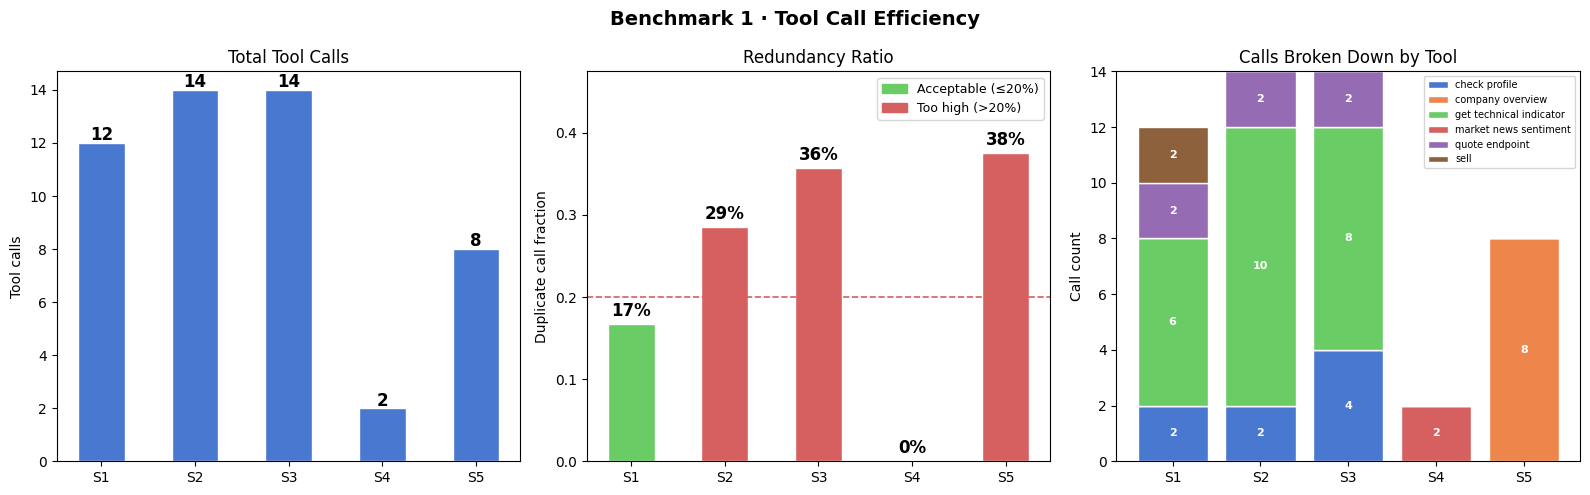

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Benchmark 1 · Tool Call Efficiency", fontsize=14, fontweight="bold")

# ── Panel 1: total calls per session ─────────────────────────────────────────
ax = axes[0]
total_calls = [r["total"] for r in b1]
bars = ax.bar(sessions, total_calls, color=C[0], edgecolor="white", width=0.5)
for bar, val in zip(bars, total_calls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Tool calls")
ax.set_title("Total Tool Calls")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Panel 2: redundancy ratio ─────────────────────────────────────────────────
ax = axes[1]
redundancy = [r["redundancy"] for r in b1]
REDUNDANCY_THRESHOLD = 0.20
colors = [C[3] if v > REDUNDANCY_THRESHOLD else C[2] for v in redundancy]
bars = ax.bar(sessions, redundancy, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, redundancy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.0%}", ha="center", fontsize=12, fontweight="bold")
ax.axhline(REDUNDANCY_THRESHOLD, color=C[3], linestyle="--", linewidth=1.2, label=f"Threshold ({REDUNDANCY_THRESHOLD:.0%})")
ax.set_ylim(0, max(redundancy + [REDUNDANCY_THRESHOLD]) + 0.1)
ax.set_ylabel("Duplicate call fraction")
ax.set_title("Redundancy Ratio")
ax.legend(fontsize=9)
good = mpatches.Patch(color=C[2], label=f"Acceptable (≤{REDUNDANCY_THRESHOLD:.0%})")
bad  = mpatches.Patch(color=C[3], label=f"Too high (>{REDUNDANCY_THRESHOLD:.0%})")
ax.legend(handles=[good, bad], fontsize=9)

# ── Panel 3: stacked bar of calls per tool across all sessions ─────────────────
ax = axes[2]
all_tool_names = sorted({name for r in b1 for name in r["per_tool"]})
x = np.arange(len(sessions))
bottoms = np.zeros(len(sessions))
for k, tool in enumerate(all_tool_names):
    vals = [r["per_tool"].get(tool, 0) for r in b1]
    bars = ax.bar(x, vals, bottom=bottoms, label=tool.replace("_", " "),
                  color=C[k % len(C)], edgecolor="white")
    for bar, val, bot in zip(bars, vals, bottoms):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                    str(val), ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottoms += np.array(vals)
ax.set_xticks(x)
ax.set_xticklabels(sessions)
ax.set_ylabel("Call count")
ax.set_title("Calls Broken Down by Tool")
ax.legend(fontsize=7, loc="upper right", ncol=1)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("b1_tool_efficiency.png", bbox_inches="tight")
plt.show()

## 📌 Benchmark 2 — Code Execution Success Rate
**What:** Fraction of `code_executor` turns that complete without a Python error on the first attempt.
**Why:** Every failed code block forces the advisor to iterate, burning extra LLM turns and tool calls. A low rate points to poor code generation quality or overly complex analysis scripts.

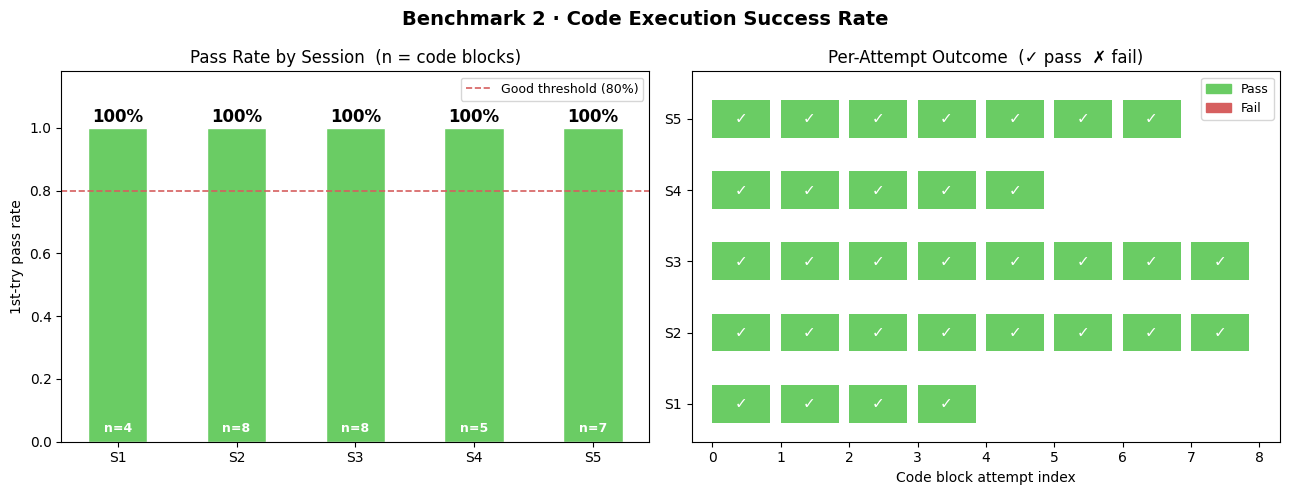

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Benchmark 2 · Code Execution Success Rate", fontsize=14, fontweight="bold")

# ── Panel 1: success rate per session ─────────────────────────────────────────
ax = axes[0]
rates  = [sum(r)/len(r) if r else 0 for r in b2]
totals = [len(r) for r in b2]
colors = [C[2] if v >= 0.8 else (C[1] if v >= 0.5 else C[3]) for v in rates]
bars   = ax.bar(sessions, rates, color=colors, edgecolor="white", width=0.5)
for bar, rate, total in zip(bars, rates, totals):
    label = f"{rate:.0%}" if total > 0 else "N/A"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            label, ha="center", fontsize=12, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, 0.03,
            f"n={total}", ha="center", fontsize=9, color="white", fontweight="bold")
ax.axhline(0.8, color=C[3], linestyle="--", linewidth=1.2, label="Good threshold (80%)")
ax.set_ylim(0, 1.18)
ax.set_ylabel("1st-try pass rate")
ax.set_title("Pass Rate by Session  (n = code blocks)")
ax.legend(fontsize=9)

# ── Panel 2: per-attempt strip across all sessions ────────────────────────────
ax2 = axes[1]
y_pos, y_labels = 0, []
for s_label, outcomes in zip(sessions, b2):
    for k, passed in enumerate(outcomes):
        color = C[2] if passed else C[3]
        ax2.add_patch(plt.Rectangle((k, y_pos + 0.1), 0.85, 0.8,
                                     color=color, lw=0))
        ax2.text(k + 0.42, y_pos + 0.5, "✓" if passed else "✗",
                 ha="center", va="center", color="white",
                 fontsize=11, fontweight="bold")
    y_labels.append((y_pos + 0.5, s_label))
    y_pos += 1.5

if y_pos == 0:
    ax2.text(0.5, 0.5, "No code blocks\ndetected", ha="center", va="center",
             transform=ax2.transAxes, fontsize=12)
    ax2.axis("off")
else:
    ax2.set_xlim(-0.3, max(len(r) for r in b2) + 0.3)
    ax2.set_ylim(-0.3, y_pos)
    ax2.set_yticks([y for y, _ in y_labels])
    ax2.set_yticklabels([l for _, l in y_labels])
    ax2.set_xlabel("Code block attempt index")
    ax2.set_title("Per-Attempt Outcome  (✓ pass  ✗ fail)")
    p = mpatches.Patch(color=C[2], label="Pass")
    f = mpatches.Patch(color=C[3], label="Fail")
    ax2.legend(handles=[p, f], fontsize=9)

plt.tight_layout()
plt.savefig("b2_code_success.png", bbox_inches="tight")
plt.show()

---
## 📌 Benchmark 3 — Evidence Quality
**What:** When the agent asks the human for trade approval, how strong is the evidence it provides?  
**Why:** The human can only make a good yes/no decision if the agent presents specific, relevant, and decision-grade support. Thin or generic requests are a HITL failure.

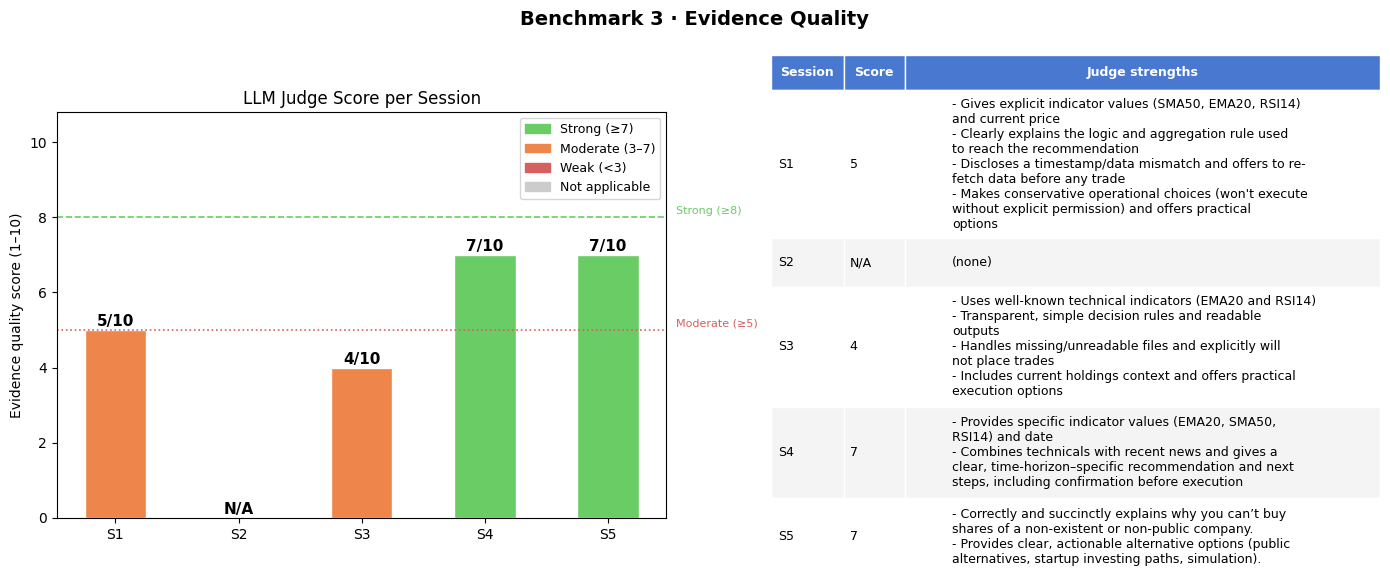

In [ ]:
import textwrap

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Benchmark 3 · Evidence Quality", fontsize=14, fontweight="bold")

# ── Panel 1: judge scores ─────────────────────────────────────────────────────
ax = axes[0]
scores = [r["score"] for r in b3]
plot_scores = [s if s is not None else np.nan for s in scores]
score_colors = [C[2] if (isinstance(s, (int, float)) and s >= 7) else (C[1] if (isinstance(s, (int, float)) and s >= 3) else C[3]) for s in scores if s is not None]
bars = ax.bar(sessions, [s if s is not None else 0 for s in scores], color=[C[2] if (isinstance(s, (int, float)) and s >= 7) else (C[1] if (isinstance(s, (int, float)) and s >= 3) else C[3]) for s in scores], edgecolor="white", width=0.5)
for bar, val in zip(bars, scores):
    label = f"{val}/10" if val is not None else "N/A"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            label, ha="center", fontsize=11, fontweight="bold")
ax.axhline(8, color=C[2], linestyle="--", linewidth=1.2)
ax.axhline(5, color=C[3], linestyle=":",  linewidth=1.2)
ax.text(len(sessions) - 0.45, 8.1, "Strong (≥8)", color=C[2], fontsize=8)
ax.text(len(sessions) - 0.45, 5.1, "Moderate (≥5)",  color=C[3], fontsize=8)
ax.set_ylim(0, 10.8)
ax.set_ylabel("Evidence quality score (1–10)")
ax.set_title("LLM Judge Score per Session")
g = mpatches.Patch(color=C[2], label="Strong (≥7)")
m = mpatches.Patch(color=C[1], label="Moderate (3–7)")
p = mpatches.Patch(color=C[3], label="Weak (<3)")
n = mpatches.Patch(color="#cccccc", label="Not applicable")
ax.legend(handles=[g, m, p, n], fontsize=9)

# ── Panel 2: table of judge rationale snippets ─────────────────────────────────
ax2 = axes[1]
ax2.axis("off")
def _format_strengths(strengths, width=54):
    if not strengths:
        return "(none)"
    lines = []
    for item in strengths:
        wrapped = textwrap.fill(str(item), width=width)
        lines.append(f"- {wrapped}")
    return "\n".join(lines)

table_data = [[s, (str(r["score"]) if r["score"] is not None else "N/A"), _format_strengths(r.get("strengths", []))] for s, r in zip(sessions, b3)]
tbl = ax2.table(
    cellText=table_data,
    colLabels=["Session", "Score", "Judge strengths"],
    cellLoc="left", loc="center",
    colWidths=[0.12, 0.10, 0.78],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.4)
for i, row in enumerate(table_data, start=1):
    line_count = row[2].count("\n") + 1
    row_h = max(0.12, 0.05 + 0.035 * line_count)
    for c in range(3):
        tbl[(i, c)].set_height(row_h)
    tbl[(i, 2)].get_text().set_wrap(True)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("white")
    if r == 0:
        cell.set_facecolor(C[0])
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#f4f4f4")

plt.tight_layout()
plt.savefig("b3_evidence_quality.png", bbox_inches="tight")
plt.show()

## 📌 Benchmark 4 — Human Instruction Adherence
**What:** After each human message, does the advisor's response incorporate the human's input?
Two sub-measures:
- **Keyword overlap** — what fraction of meaningful words in the human's message re-appear in the advisor's next reply. Captures whether the agent actually *read* what the human said.
- **Constraint acknowledgement** — when the human issues an explicit directive (`"only", "don't", "focus on", "avoid"…`), does the advisor acknowledge it in the response?

**Why:** A high-quality HITL agent doesn't just pause for human input — it *uses* that input to course-correct.


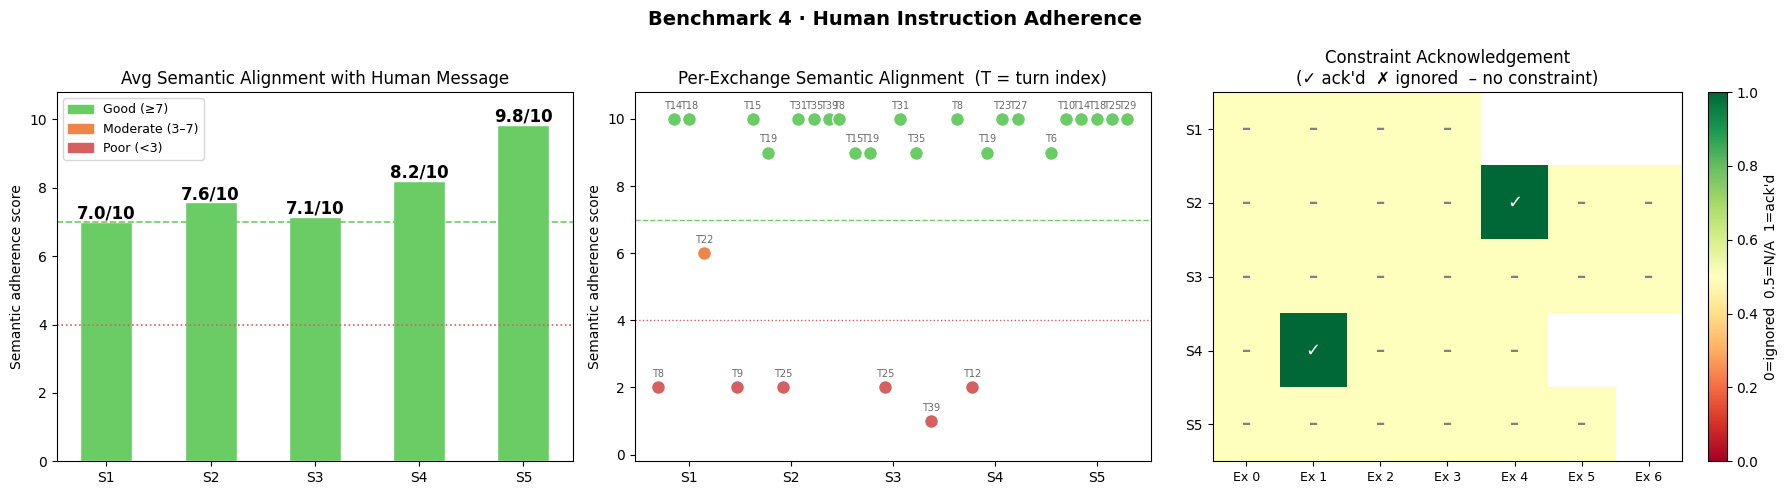

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Benchmark 4 · Human Instruction Adherence", fontsize=14, fontweight="bold")

# ── Panel 1: mean semantic score per session ───────────────────────────────────
ax = axes[0]
mean_scores = []
for exchanges in b4:
    if exchanges:
        mean_scores.append(np.mean([e["score"] for e in exchanges]))
    else:
        mean_scores.append(0.0)

colors = [C[2] if v >= 7 else (C[1] if v >= 3 else C[3]) for v in mean_scores]
bars   = ax.bar(sessions, mean_scores, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, mean_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}/10", ha="center", fontsize=12, fontweight="bold")
ax.axhline(7, color=C[2], linestyle="--", linewidth=1.2)
ax.axhline(4, color=C[3], linestyle=":",  linewidth=1.2)
ax.set_ylim(0, 10.8)
ax.set_ylabel("Semantic adherence score")
ax.set_title("Avg Semantic Alignment with Human Message")
g = mpatches.Patch(color=C[2], label="Good (≥7)")
m = mpatches.Patch(color=C[1], label="Moderate (3–7)")
p = mpatches.Patch(color=C[3], label="Poor (<3)")
ax.legend(handles=[g, m, p], fontsize=9)

# ── Panel 2: per-exchange detail (scatter each exchange score) ────────────────
ax2 = axes[1]
for s_i, (s_label, exchanges) in enumerate(zip(sessions, b4)):
    for e_i, ex in enumerate(exchanges):
        color = C[2] if ex["score"] >= 7 else (C[1] if ex["score"] >=3 else C[3])
        ax2.scatter(s_i + (e_i - len(exchanges)/2) * 0.15, ex["score"],
                    s=100, color=color, edgecolors="white", zorder=3)
        ax2.text(s_i + (e_i - len(exchanges)/2) * 0.15, ex["score"] + 0.3,
                 f"T{ex['turn']}", ha="center", fontsize=7, color="dimgray")

ax2.axhline(7, color=C[2], linestyle="--", linewidth=1)
ax2.axhline(4, color=C[3], linestyle=":",  linewidth=1)
ax2.set_xticks(range(len(sessions)))
ax2.set_xticklabels(sessions)
ax2.set_ylim(-0.2, 10.8)
ax2.set_ylabel("Semantic adherence score")
ax2.set_title("Per-Exchange Semantic Alignment  (T = turn index)")

# ── Panel 3: constraint acknowledgement heatmap ───────────────────────────────
ax3 = axes[2]
# Build grid: rows = sessions, cols = exchange index (up to max_exchanges)
max_ex = max((len(b) for b in b4), default=0)

if max_ex == 0:
    ax3.text(0.5, 0.5, "No human messages\nfound", ha="center", va="center",
             transform=ax3.transAxes, fontsize=11)
    ax3.axis("off")
else:
    grid   = np.full((len(sessions), max_ex), np.nan)
    labels = np.full((len(sessions), max_ex), "", dtype=object)
    for s_i, exchanges in enumerate(b4):
        for e_i, ex in enumerate(exchanges):
            if ex["has_constraint"]:
                grid[s_i, e_i]   = 1 if ex["constraint_ack"] else 0
                labels[s_i, e_i] = "✓" if ex["constraint_ack"] else "✗"
            else:
                grid[s_i, e_i]   = 0.5
                labels[s_i, e_i] = "–"

    cmap = plt.cm.RdYlGn
    masked = np.ma.masked_invalid(grid)
    im = ax3.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect="auto")

    for s_i in range(len(sessions)):
        for e_i in range(max_ex):
            if not np.isnan(grid[s_i, e_i]):
                ax3.text(e_i, s_i, labels[s_i, e_i], ha="center", va="center",
                         fontsize=13, fontweight="bold",
                         color="white" if grid[s_i, e_i] != 0.5 else "gray")

    ax3.set_yticks(range(len(sessions)))
    ax3.set_yticklabels(sessions)
    ax3.set_xticks(range(max_ex))
    ax3.set_xticklabels([f"Ex {i}" for i in range(max_ex)], fontsize=9)
    ax3.set_title("Constraint Acknowledgement\n(✓ ack'd  ✗ ignored  – no constraint)")
    fig.colorbar(im, ax=ax3, fraction=0.04, label="0=ignored  0.5=N/A  1=ack'd")

plt.tight_layout()
plt.savefig("b4_adherence.png", bbox_inches="tight")
plt.show()

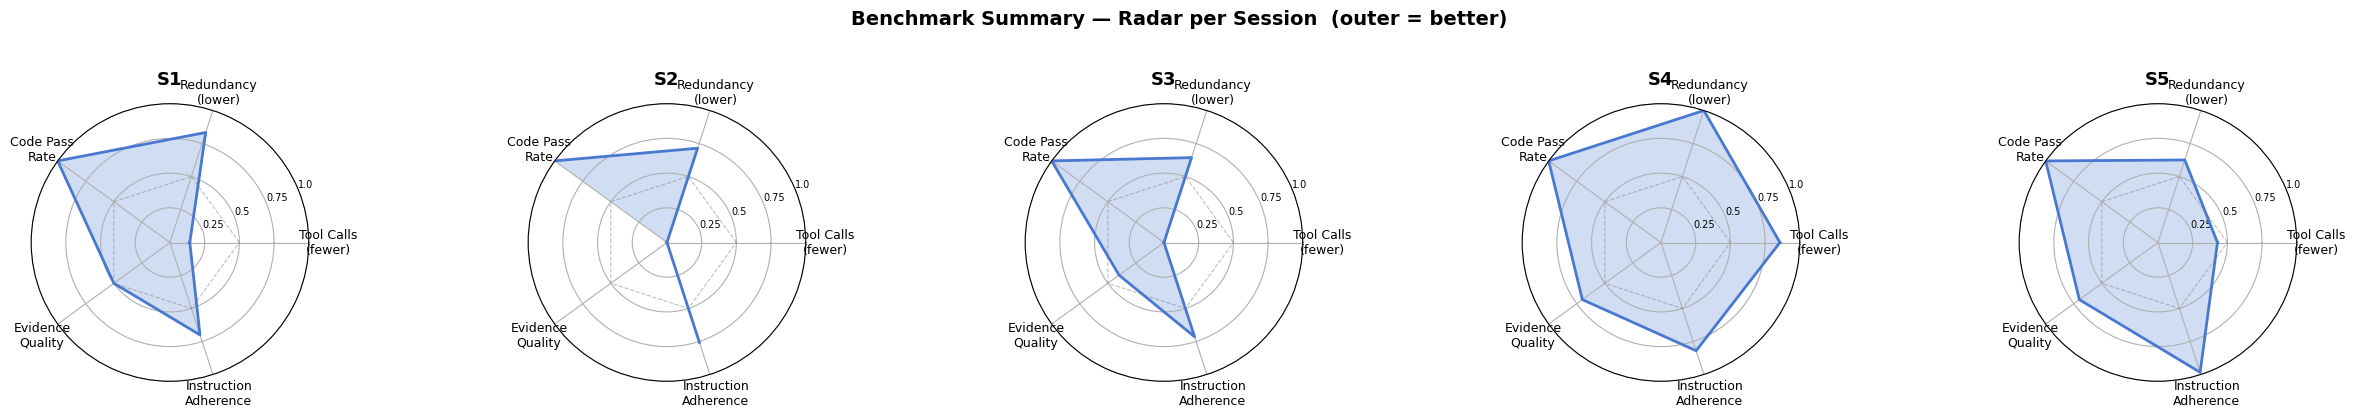


✅ All benchmarks complete. Files saved:
  • b1_tool_efficiency.png
  • b2_code_success.png
  • b3_evidence_quality.png
  • b4_adherence.png
  • benchmark_summary_radar.png


In [ ]:
# Normalise each metric to [0, 1] using absolute scales so the outer ring means the same thing everywhere.
# For metrics where lower is better (redundancy, decision turn), we invert.

def safe_norm(vals, invert=False, ceiling=None):
    vals = np.array(vals, dtype=float)
    if ceiling is not None:
        vals = np.clip(vals, 0, ceiling)
        vals = vals / ceiling
    else:
        vals = np.clip(vals, 0, 1)
    return 1 - vals if invert else vals

tool_call_ceiling = max([r["total"] for r in b1] + [1])

metrics_norm = np.column_stack([
    safe_norm([r["total"] for r in b1], invert=True, ceiling=tool_call_ceiling),     # B1 total (fewer=better)
    safe_norm([r["redundancy"] for r in b1], invert=True, ceiling=1.0),              # B1 redundancy (lower=better)
    safe_norm([sum(r)/len(r) if r else 0 for r in b2], ceiling=1.0),                   # B2 pass rate (higher=better)
    safe_norm([r["score"] for r in b3], ceiling=10.0),                                # B3 evidence quality (1-10)
    safe_norm([np.mean([e["score"] for e in r]) / 10 if r else 0 for r in b4], ceiling=1.0),  # B4 semantic adherence
])

metric_labels = [
    "Tool Calls\n(fewer)", "Redundancy\n(lower)", "Code Pass\nRate",
    "Evidence\nQuality", "Instruction\nAdherence",
]
N = len(metric_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the loop

fig, axes = plt.subplots(1, len(sessions), figsize=(5 * len(sessions), 4),
                          subplot_kw=dict(polar=True))
if len(sessions) == 1:
    axes = [axes]

fig.suptitle("Benchmark Summary — Radar per Session  (outer = better)",
             fontsize=14, fontweight="bold", y=1.03)

for ax, s_label, row in zip(axes, sessions, metrics_norm):
    values = row.tolist() + row[:1].tolist()

    ax.plot(angles, values, color=C[0], linewidth=2)
    ax.fill(angles, values, color=C[0], alpha=0.25)

    # Reference circle at 0.5
    ref = [0.5] * (N + 1)
    ax.plot(angles, ref, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

    ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=7)
    ax.set_title(s_label, fontsize=13, fontweight="bold", pad=14)

plt.tight_layout()
plt.savefig("benchmark_summary_radar.png", bbox_inches="tight", dpi=130)
plt.show()

print("\n✅ All benchmarks complete. Files saved:")
for f in ["b1_tool_efficiency.png", "b2_code_success.png",
          "b3_evidence_quality.png",
          "b4_adherence.png",        "benchmark_summary_radar.png"]:
    print(f"  • {f}")